|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>Tokenizations and embeddings<h1>|
|<h2>Section:</h2>|<h1>Words to tokens to numbers<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge HELPER: Token count by subword length<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

!pip install tiktoken
import tiktoken

In [2]:
# GPT-4's tokenizer
tokenizer = tiktoken.get_encoding('cl100k_base')

# Exercise 1: Token count by word length

In [3]:
import requests
import re
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = tokenizer.encode(text)

In [6]:
len(w)

3

In [7]:
# split by punctuation
words = re.split(r'([,.:;—?_!"“()\']|--|\s)',text)
words = [item.strip() for item in words if item.strip()]

tokenCount = np.zeros((len(words),2),dtype=int)

for idx,w in enumerate(words):
  tokenCount[idx,0] =  len(w) # first column is the length of the word
  tokenCount[idx,1] =  len(tokenizer.encode(w))# second column is the number of tokens

In [8]:
plt.figure(figsize=(12,4))

offsetsX = np.random.randn(len(words))/20 # appropriately scaled random scatter
offsetsY = np.random.randn(len(words))/20

plt.plot(tokenCount[:,0]+offsetsX,tokenCount[:,1]+offsetsY,'k.',alpha=.5)
plt.gca().set(xlabel='Word lengths',ylabel='Encoded token count',xticks=np.arange(max(tokenCount[:,0])+1),yticks=np.arange(max(tokenCount[:,1])+1),
               title='Character count vs. token count')

plt.show()

# Exercise 2: Encoding of 14-character words

In [16]:
# find words with characters
wordsWith14Chars = set(np.where(tokenCount[:,0]==14)[0])

# print their tokens
for idx in wordsWith14Chars:
  this_decode = [tokenizer.decode([token]) for token in tokenizer.encode(words[idx])]
  print(f'"{words[idx]}" comprises {this_decode}')

"aforementioned" comprises ['a', 'fore', 'mentioned']
"constellations" comprises ['const', 'ell', 'ations']
"specialisation" comprises ['special', 'isation']
"conversational" comprises ['con', 'vers', 'ational']
"Time-Dimension" comprises ['Time', '-D', 'imension']
"Psychologist’s" comprises ['Psych', 'ologist', '’s']
"north-eastward" comprises ['north', '-east', 'ward']
"Undergrounders" comprises ['Under', 'ground', 'ers']
"interpretation" comprises ['interpret', 'ation']
"discriminating" comprises ['disc', 'rim', 'inating']
"mountaineering" comprises ['mount', 'aine', 'ering']
"mathematicians" comprises ['math', 'ematic', 'ians']
"ill-controlled" comprises ['ill', '-controlled']
"Psychologist’s" comprises ['Psych', 'ologist', '’s']
"North-eastward" comprises ['North', '-east', 'ward']
"interrogations" comprises ['inter', 'rog', 'ations']
"self-deception" comprises ['self', '-de', 'ception']
"differentiated" comprises ['different', 'iated']
"expostulations" comprises ['ex', 'post', 'u

# Exercise 3: Token efficiency

In [18]:
# "more efficient" word: lots of letters and few tokens
# "less efficient" word: few letters and many tokens
moreEfficient = np.where( (tokenCount[:,0]==17) & (tokenCount[:,1]==2) )[0]
lessEfficient = np.where( (tokenCount[:,0]==10) & (tokenCount[:,1]==6) )[0]

print(f'A very efficient word:\n  "{words[moreEfficient[0]]}" has {tokenCount[moreEfficient[0],0]} letters and {tokenCount[moreEfficient[0],1]} tokens.\n')
print(f'An inefficient word:\n "{words[lessEfficient[0]]}" has {tokenCount[lessEfficient[0],0]} letters and {tokenCount[lessEfficient[0],1]} tokens.')

A very efficient word:
  "three-dimensional" has 17 letters and 2 tokens.

An inefficient word:
 "gynæceum’s" has 10 letters and 6 tokens.


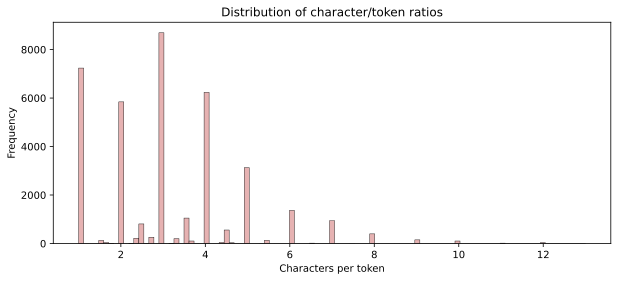

In [19]:
# "efficiency" as characters/tokens
efficiency = tokenCount[:,0] / tokenCount[:,1]

# show a historgram
plt.figure(figsize=(10,4))
plt.hist(efficiency,color=[.9,.7,.7],edgecolor='k',linewidth=.4,bins='fd')
plt.gca().set(xlabel='Characters per token',ylabel='Frequency',title='Distribution of character/token ratios')
plt.show()

In [20]:
# find the most and least efficiently tokenized words
max_efficiency = np.max(efficiency)
min_efficiency = np.min(efficiency)

# find all the words with those efficiency values
most_efficient_words = np.where(efficiency==max_efficiency)[0]
least_efficient_words = np.where(efficiency==min_efficiency)[0]

# find and print the unique words with max-efficiency score
most_efficient_words = list(set([words[i] for i in most_efficient_words]))
least_efficient_words = list(set([words[i] for i in least_efficient_words]))

print('MOST EFFICIENT WORDS:')
for w in most_efficient_words:
  print(f'"{w}" has {max_efficiency} characters per token')


# repeat for min-efficiency score
for w in least_efficient_words:
  print(f'"{w}" has {min_efficiency} characters per token')




MOST EFFICIENT WORDS:
"advertisement" has 13.0 characters per token
"communication" has 13.0 characters per token
":" has 1.0 characters per token
"a" has 1.0 characters per token
"_" has 1.0 characters per token
"(" has 1.0 characters per token
"." has 1.0 characters per token
"D" has 1.0 characters per token
"," has 1.0 characters per token
"I" has 1.0 characters per token
"!" has 1.0 characters per token
"A" has 1.0 characters per token
"’" has 1.0 characters per token
"—" has 1.0 characters per token
"?" has 1.0 characters per token
"…" has 1.0 characters per token
"‘I" has 1.0 characters per token
")" has 1.0 characters per token
"XV" has 1.0 characters per token
"H" has 1.0 characters per token
"]" has 1.0 characters per token
"V" has 1.0 characters per token
"X" has 1.0 characters per token
"”" has 1.0 characters per token
"“" has 1.0 characters per token
"G" has 1.0 characters per token
";" has 1.0 characters per token


# Exercise 4: Tokens in separated words vs. text

In [ ]:
# unique set of words as we've split them up
uniqueWords =
print(f'There are {} unique words in The Time Machine according to our split.')

In [ ]:
# random token
token_idx =

# non-random tokens to try
# token_idx = 1879#,5030#,716

# find the words (from our split) in The Time Machine that contain that token
words_with_token = [w for w in uniqueWords if

# find the context (from the full encoding) surrounding each token appearance
seqs_with_token = ==token_idx

# print the token
print(f'Token {token_idx} is "{tokenizer.decode([token_idx])}"\n\n')

# its occurance in our manually split words
print(f'*** Our manual word split: Token appears {len(words_with_token)} times, including:\n----------------')
for w in words_with_token:


# its occurances in the GPT encoding
print(f'\n\n*** From encoding the full text: This token appears {sum(seqs_with_token)} times, including:\n----------------')
for s in np.where(seqs_with_token)[0]:


# Exercise 5: Do more frequent words have fewer tokens?

In [ ]:
# the unique words, as a list instead of a set (for indexing)
uniqueWords = # OK to overwrite the variable...

# initialize results vectors
wordFreq = np.zeros(,dtype=int)
numTokens = np.zeros(len(uniqueWords),)


# loop through all unique words
for i,uword in enumerate(uniqueWords):

  # count the number of times that word appears


  # count the number of tokens in that word


In [ ]:
plt.figure(figsize=(10,4))
plt.plot(
plt.gca().set(xlabel='Word frequency (log)',ylabel='Encoding length',xscale='log')
plt.show()

In [ ]:
wordFreqidx = np.argsort(wordFreq)[::-1]
for i in wordFreqidx[:20]:
  print(f'{} appearances of "{}"')

# Exercise 6: Fake words from real tokens

In [ ]:
nTokens = .00003 # hmm...

# choose some random tokens
randtokens = np.random.choice

# print the individual tokens
for t in randtokens:
  print(f'Token {t} is "{tokenizer.decode([t])}"')

# fake word without whitespace
fakeword = re.sub

print(f'\nThe fake word is "{fakeword}"')